# Moby Bikes: bike-type classification evaluated on unseen bikes

`main.ipynb` evaluates the models with a random 80/20 split of rows. The data holds repeated snapshots of the same bikes (one snapshot per bike roughly every 30 minutes), so the same bike, often parked at the same GPS position, appears in both the training and the test set. A model can then score highly by recognising individual bikes rather than learning what distinguishes a bike type.

This notebook repeats the classification with a split **grouped by `BikeID`**: every bike is either entirely in training or entirely in testing. It uses the same cleaning, features, pipelines and model settings as `main.ipynb`.

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import os
os.makedirs('figures', exist_ok=True)

## Load and clean the data (same steps as `main.ipynb`)

The only difference: `BikeID` is kept aside as the grouping key. It is **not** used as a model feature.

In [2]:
DATA_PATH = "data/moby-bikes-historical-data-092020.csv"
df = pd.read_csv(DATA_PATH)
df['Battery'] = df['Battery'].fillna(df['Battery'].median())
df['HarvestTime'] = pd.to_datetime(df['HarvestTime'])
df = df[(df['Latitude'] != 0) | (df['Longitude'] != 0)]
df_cleaned = df[df['Battery'] >= 0].copy()
df_cleaned['Hour'] = df_cleaned['HarvestTime'].dt.hour
df_cleaned['DayOfWeek'] = df_cleaned['HarvestTime'].dt.dayofweek
print('Rows after cleaning:', len(df_cleaned))

Rows after cleaning: 26200


## How many bikes are behind the rows?

In [3]:
print('Distinct bikes:', df_cleaned['BikeID'].nunique())
print('Distinct snapshot times:', df_cleaned['HarvestTime'].nunique())
print('Median rows per bike:', df_cleaned.groupby('BikeID').size().median())
print('Max bike types per bike (1 = a bike never changes type):', df_cleaned.groupby('BikeID')['BikeTypeName'].nunique().max())
summary = df_cleaned.groupby('BikeTypeName').agg(rows=('BikeID', 'size'), bikes=('BikeID', 'nunique'))
summary['share_of_rows_%'] = (100 * summary['rows'] / summary['rows'].sum()).round(2)
summary

Distinct bikes: 89
Distinct snapshot times: 350
Median rows per bike: 330.0
Max bike types per bike (1 = a bike never changes type): 1


,rows,bikes,share_of_rows_%
BikeTypeName,,,
DUB-General,25244,85,96.35
Private,349,1,1.33
Workshop,607,3,2.32


## Features (same as `main.ipynb`)

In [4]:
numeric_features = ['Battery', 'Latitude', 'Longitude', 'EBikeProfileID', 'EBikeStateID', 'Hour', 'DayOfWeek']
bool_features = ['IsEBike', 'IsMotor', 'IsSmartLock']
X = df_cleaned[numeric_features + bool_features]
y = df_cleaned['BikeTypeName']
groups = df_cleaned['BikeID']
CLASSES = ['DUB-General', 'Private', 'Workshop']

def build_pipeline(model, numeric_feats, bool_feats):
    preprocessor = ColumnTransformer([
        ('num', StandardScaler(), numeric_feats),
        ('bool', 'passthrough', bool_feats)
    ])
    return Pipeline([('pre', preprocessor), ('model', model)])

def make_models():
    return {
        'Dummy Baseline': DummyClassifier(strategy='most_frequent'),
        'Logistic Regression': build_pipeline(LogisticRegression(max_iter=1000, solver='lbfgs'), numeric_features, bool_features),
        'Random Forest': build_pipeline(RandomForestClassifier(n_estimators=100, random_state=42), numeric_features, bool_features),
        'MLP Neural Network': build_pipeline(MLPClassifier(hidden_layer_sizes=(50, 25), max_iter=500, random_state=42), numeric_features, bool_features),
    }

## Reference: the original random row split

Same split as `main.ipynb` (80/20, stratified, `random_state=42`). This shows how many test rows come from bikes that are also in the training set.

In [5]:
X_train, X_test, y_train, y_test, g_train, g_test = train_test_split(
    X, y, groups, test_size=0.2, random_state=42, stratify=y)
print('Test rows whose bike is also in training: {:.1%}'.format(g_test.isin(set(g_train)).mean()))
rf_random = make_models()['Random Forest'].fit(X_train, y_train)
pred = rf_random.predict(X_test)
print('Random Forest, random row split: accuracy {:.4f}, macro-F1 {:.4f}'.format(
    accuracy_score(y_test, pred), f1_score(y_test, pred, average='macro', labels=CLASSES)))

Test rows whose bike is also in training: 100.0%


Random Forest, random row split: accuracy 0.9992, macro-F1 0.9902


## Grouped evaluation: unseen bikes only

`StratifiedGroupKFold` with 5 folds, grouped by `BikeID`. Each bike lands in exactly one test fold, and the folds try to spread each class's bikes evenly. Predictions from the 5 test folds are pooled, so every row is predicted once by a model that never saw that bike.

The table below shows, for each fold, how many bikes of each type are in the test fold and how many are left for training.

In [6]:
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
splits = list(cv.split(X, y, groups))
rows = []
for k, (tr, te) in enumerate(splits, 1):
    for c in CLASSES:
        rows.append({'fold': k, 'class': c,
                     'test_bikes': groups.iloc[te][y.iloc[te] == c].nunique(),
                     'train_bikes': groups.iloc[tr][y.iloc[tr] == c].nunique()})
fold_table = pd.DataFrame(rows).pivot(index='fold', columns='class', values=['test_bikes', 'train_bikes'])
fold_table

test_bikes                  train_bikes                 
class DUB-General Private Workshop DUB-General Private Workshop
fold                                                           
1              16       0        2          69       1        1
2              17       0        0          68       1        3
3              17       1        0          68       0        3
4              18       0        0          67       1        3
5              17       0        1          68       1        2

In [7]:
oof = {}
for name in make_models():
    pred = pd.Series(index=y.index, dtype=object)
    for tr, te in splits:
        model = make_models()[name]
        model.fit(X.iloc[tr], y.iloc[tr])
        pred.iloc[te] = model.predict(X.iloc[te])
    oof[name] = pred

results = []
for name, pred in oof.items():
    rec = recall_score(y, pred, labels=CLASSES, average=None, zero_division=0)
    results.append({'Model': name,
                    'Accuracy': accuracy_score(y, pred),
                    'Macro-F1 (3 classes)': f1_score(y, pred, labels=CLASSES, average='macro', zero_division=0),
                    **{f'Recall {c}': r for c, r in zip(CLASSES, rec)}})
grouped_results = pd.DataFrame(results).set_index('Model').round(4)
grouped_results

,Accuracy,Macro-F1 (3 classes),Recall DUB-General,Recall Private,Recall Workshop
Model,,,,,
Dummy Baseline,0.9635,0.3271,1.0000,0.0,0.0
Logistic Regression,0.9635,0.3271,1.0000,0.0,0.0
Random Forest,0.9614,0.3268,0.9978,0.0,0.0
MLP Neural Network,0.9505,0.3249,0.9865,0.0,0.0


## Random Forest on unseen bikes: classification report and confusion matrix

              precision    recall  f1-score   support

 DUB-General     0.9634    0.9978    0.9803     25244
     Private     0.0000    0.0000    0.0000       349
    Workshop     0.0000    0.0000    0.0000       607

    accuracy                         0.9614     26200
   macro avg     0.3211    0.3326    0.3268     26200
weighted avg     0.9283    0.9614    0.9445     26200



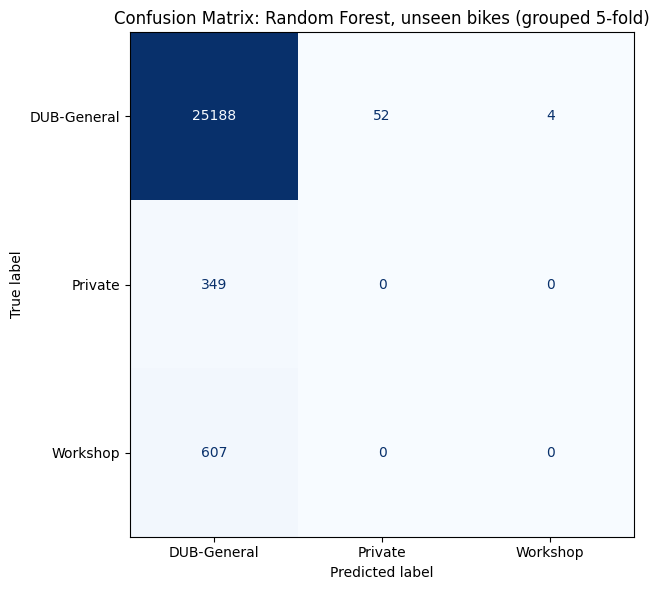

In [8]:
pred_rf = oof['Random Forest']
print(classification_report(y, pred_rf, labels=CLASSES, zero_division=0, digits=4))
cm = confusion_matrix(y, pred_rf, labels=CLASSES)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix: Random Forest, unseen bikes (grouped 5-fold)', fontsize=12)
plt.tight_layout()
plt.savefig('figures/confusion_matrix_rf_grouped.png', dpi=150, bbox_inches='tight')
plt.show()

## Which classes can be evaluated on unseen bikes?

In [9]:
for c in CLASSES:
    n = df_cleaned.loc[y == c, 'BikeID'].nunique()
    if n == 1:
        verdict = 'cannot be evaluated: when its only bike is in the test fold, the model has no training rows of this class'
    elif n < 5:
        verdict = 'can be evaluated, but only on {} bikes, so the recall is very uncertain'.format(n)
    else:
        verdict = 'can be evaluated'
    print(f'{c}: {n} bike(s) -> {verdict}')

DUB-General: 85 bike(s) -> can be evaluated
Private: 1 bike(s) -> cannot be evaluated: when its only bike is in the test fold, the model has no training rows of this class
Workshop: 3 bike(s) -> can be evaluated, but only on 3 bikes, so the recall is very uncertain
